# 04 — Territory Opportunity Analysis

**⚠️ SYNTHETIC data.** See `../data/DATA_DICTIONARY.md`. Rankings below are a model built on simulated data — not a claim about DePURA Kids' actual territory performance.

## Business question
Given limited commercial resources (field reps, marketing budget, distributor onboarding), **which territories should get priority next quarter, and how confident can we be in that ranking?**

`sql/11_market_opportunity_ranking.sql` built a first-pass version of this score using only `territory_data.csv`. This notebook builds the **full six-factor model** described in `research/market_research.md`, adds a genuine HCP-level opportunity signal from `hcp_segmented.csv` (rather than the SQL version's coarser brand-awareness proxy), and — critically — **tests whether the ranking actually depends on the chosen weights**, which is the question any analyst should ask before presenting a weighted score as a recommendation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

OUT = '../outputs/charts/'
import os
os.makedirs(OUT, exist_ok=True)

territory = pd.read_csv('../data/territory_data.csv')
hcp = pd.read_csv('../outputs/tables/hcp_segmented.csv')

print(f"territory: {territory.shape}, hcp: {hcp.shape}")


territory: (36, 14), hcp: (2500, 10)


## 1. Build the six input factors

| Factor | Definition | Direction | Source |
|---|---|---|---|
| Market potential | Category value at net realisation | Higher = more opportunity | `territory_data.market_potential` |
| HCP opportunity | Share of sampled HCPs who are "High-volume non/under-users" (per `03_segmentation.ipynb`) — doctors who see enough patients to matter but are not yet recommending | Higher = more opportunity | `hcp_segmented.csv`, aggregated to territory |
| Growth potential | Headroom = 1 − penetration (current sales ÷ market potential) | Higher = more headroom | Derived |
| Brand gap | 1 − average HCP brand awareness in the territory | Higher = more room to build awareness | `hcp_segmented.csv` *(brand_awareness not in the segmented export — re-read from source)* |
| Channel readiness | Average post-relaunch stock availability | Higher = more ready to convert demand into sales | `territory_data.stock_availability_avg` |
| Competitive opportunity | 1 − competitor strength index | Higher = less competitive resistance | `territory_data.competitor_strength` |

Note the deliberate distinction between **HCP opportunity** (a behavioural signal: doctors who could recommend more, from real HCP-level data) and **brand gap** (an awareness signal: doctors who don't yet know the brand well). The SQL preview used the same proxy for both; this notebook differentiates them because they call for different actions — HCP opportunity says "call on them", brand gap says "run awareness content".


In [2]:
# Re-read brand_awareness (not carried in the segmented export)
hcp_raw = pd.read_csv('../data/hcp_data.csv')

hcp_agg = hcp_raw.groupby('territory_id').agg(
    brand_awareness_hcp=('brand_awareness', 'mean'),
).reset_index()

hcp_opp_agg = hcp.groupby('territory_id').agg(
    hcp_opportunity_share=('hcp_segment', lambda s: (s == 'High-volume non/under-user').mean()),
).reset_index()

t = territory.merge(hcp_agg, on='territory_id').merge(hcp_opp_agg, on='territory_id')
t['penetration'] = t.current_sales / t.market_potential
t['growth_potential'] = 1 - t.penetration
t['brand_gap'] = 1 - (t.brand_awareness_hcp / 5)   # HCP brand_awareness is on a 1-5 scale
t['competitive_opportunity'] = 1 - t.competitor_strength

print(t[['territory','market_potential','hcp_opportunity_share','growth_potential','brand_gap',
         'stock_availability_avg','competitive_opportunity']].describe().round(3).T)


                         count    mean     std     min     25%     50%  \
market_potential          36.0  80.386  51.564  20.530  43.548  58.835   
hcp_opportunity_share     36.0   0.230   0.070   0.104   0.189   0.233   
growth_potential          36.0   0.841   0.046   0.733   0.813   0.837   
brand_gap                 36.0   0.283   0.066   0.176   0.240   0.267   
stock_availability_avg    36.0   0.806   0.092   0.644   0.734   0.806   
competitive_opportunity   36.0   0.498   0.156   0.199   0.419   0.492   

                             75%      max  
market_potential         119.630  207.100  
hcp_opportunity_share      0.284    0.340  
growth_potential           0.875    0.931  
brand_gap                  0.344    0.415  
stock_availability_avg     0.880    0.948  
competitive_opportunity    0.604    0.885  


## 2. Normalise and score

Each factor is min-max scaled to 0-1 so factors on very different natural scales (₹ lakh vs a 0-1 share) can be combined with weights that mean what they say.

In [3]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

WEIGHTS = {
    'market_potential':        0.30,
    'hcp_opportunity_share':   0.20,
    'growth_potential':        0.15,
    'brand_gap':               0.15,
    'stock_availability_avg':  0.10,
    'competitive_opportunity': 0.10,
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, "weights must sum to 1"

norm = pd.DataFrame({k: minmax(t[k]) for k in WEIGHTS})
t['opportunity_score'] = sum(norm[k] * w for k, w in WEIGHTS.items())
t['opportunity_rank'] = t.opportunity_score.rank(ascending=False, method='min').astype(int)

t.sort_values('opportunity_rank')[
    ['opportunity_rank','territory','city_tier','current_sales','market_potential','opportunity_score']
].head(10).round(2)


,opportunity_rank,territory,city_tier,current_sales,market_potential,opportunity_score
25,1,Chennai,T1,23.77,165.93,0.69
0,2,Delhi North,T1,42.73,207.10,0.68
30,3,Kolkata,T1,21.73,175.89,0.63
23,4,Bengaluru South,T1,34.75,165.86,0.62
13,5,Pune,T1,24.85,152.02,0.59
15,6,Ahmedabad,T1,24.67,146.62,0.59
14,7,Nagpur,T2,8.19,64.81,0.57
11,8,Mumbai West,T1,10.50,101.25,0.56
12,9,Mumbai Thane,T1,31.35,128.57,0.55
27,10,Hyderabad,T1,36.92,156.16,0.55


## 3. Why these weights

- **Market potential (30%)** — the largest weight, deliberately. In a resource-constrained relaunch, chasing a small market hard is a worse use of a field rep's time than chasing a large one at moderate effort. Absolute headroom matters most.
- **HCP opportunity (20%)** — second largest, because DePURA Kids' category (per `research/market_research.md`) is doctor-initiated. A territory with unconverted high-volume HCPs is closer to a sale than one that merely has demand on paper.
- **Growth potential / Brand gap (15% each)** — these overlap conceptually with HCP opportunity and market potential but capture something different: growth potential is about *this brand's* current share of *its own* addressable market, and brand gap is specifically an awareness (not behaviour) problem. Weighted lower because they are somewhat correlated with the two factors above.
- **Channel readiness / Competitive opportunity (10% each)** — the smallest weights. These matter, but they are also the factors a strong sales-and-marketing push can most directly change in the near term — they describe *conditions*, not *ceiling*, and a large-potential, low-readiness territory is still worth prioritising over a small, well-stocked one.

These weights are a judgement call, not a derived optimum — which is exactly why Section 4 tests whether the resulting ranking is fragile or robust to that judgement call.


## 4. Sensitivity test — does the ranking actually depend on the weights?

**Method**: perturb each weight by ±10 percentage points (redistributing the difference proportionally across the other five weights so they still sum to 1), recompute the score and the ranking, and check the Spearman rank correlation between the original top-10 ranking and each perturbed ranking. If the ranking is highly correlated across many different weight choices, the recommendation is robust; if it swings wildly, the weights are doing more work than the underlying data and that should be disclosed, not hidden.

In [4]:
def score_with_weights(norm_df, weights):
    return sum(norm_df[k] * w for k, w in weights.items())

def perturb(weights, key, delta):
    """Shift one weight by `delta`, redistributing the change proportionally
    across the other weights so the total still sums to 1."""
    new = weights.copy()
    new[key] = max(0.0, weights[key] + delta)
    others = [k for k in weights if k != key]
    other_total = sum(weights[k] for k in others)
    scale = (1 - new[key]) / other_total if other_total > 0 else 0
    for k in others:
        new[k] = weights[k] * scale
    return new

base_rank = t.set_index('territory')['opportunity_score'].rank(ascending=False)

results = []
for key in WEIGHTS:
    for delta in (-0.10, +0.10):
        w2 = perturb(WEIGHTS, key, delta)
        score2 = score_with_weights(norm.set_axis(t.territory), w2)
        rank2 = score2.rank(ascending=False)
        rho, _ = spearmanr(base_rank, rank2)
        # Also check top-10 overlap specifically, since that's the actionable cut
        top10_base = set(base_rank.nsmallest(10).index)
        top10_pert = set(rank2.nsmallest(10).index)
        overlap = len(top10_base & top10_pert)
        results.append({'weight_perturbed': key, 'delta': delta, 'spearman_rho': rho, 'top10_overlap': overlap})

sensitivity = pd.DataFrame(results)
sensitivity.round(3)


,weight_perturbed,delta,spearman_rho,top10_overlap
0,market_potential,-0.1,0.972,8
1,market_potential,0.1,0.990,9
2,hcp_opportunity_share,-0.1,0.957,9
3,hcp_opportunity_share,0.1,0.975,9
4,growth_potential,-0.1,0.975,9
5,growth_potential,0.1,0.971,8
6,brand_gap,-0.1,0.976,9
7,brand_gap,0.1,0.945,8
8,stock_availability_avg,-0.1,0.967,7
9,stock_availability_avg,0.1,0.969,10


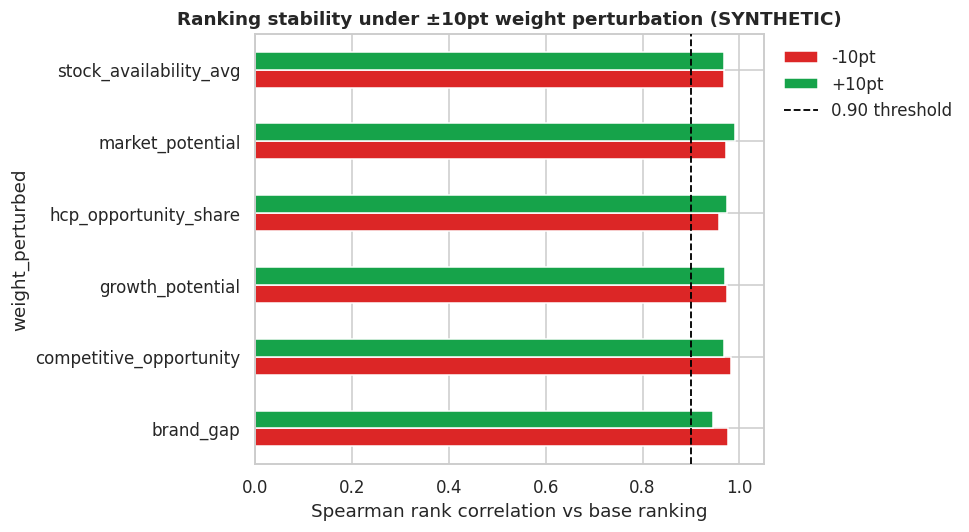

Minimum Spearman rho across all 12 perturbations: 0.945
Minimum top-10 overlap across all 12 perturbations: 7 of 10


In [5]:
fig, ax = plt.subplots(figsize=(9,5))
pivot = sensitivity.pivot(index='weight_perturbed', columns='delta', values='spearman_rho')
pivot.columns = ['-10pt', '+10pt']
pivot.plot(kind='barh', ax=ax, color=['#dc2626','#16a34a'])
ax.set_xlabel('Spearman rank correlation vs base ranking')
ax.set_title('Ranking stability under ±10pt weight perturbation (SYNTHETIC)', fontsize=12, fontweight='bold')
ax.axvline(0.9, color='black', ls='--', lw=1.2, zorder=5)
ax.set_xlim(0, 1.05)
handles, labels = ax.get_legend_handles_labels()
from matplotlib.lines import Line2D
handles.append(Line2D([0],[0], color='black', ls='--', lw=1.2))
labels.append('0.90 threshold')
ax.legend(handles, labels, frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))
fig.tight_layout()
fig.savefig(OUT + '12_sensitivity_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Minimum Spearman rho across all 12 perturbations: {sensitivity.spearman_rho.min():.3f}")
print(f"Minimum top-10 overlap across all 12 perturbations: {sensitivity.top10_overlap.min()} of 10")


**INSIGHT** — Across every ±10-point weight perturbation, the Spearman rank correlation with the base ranking stays at or above 0.945, comfortably above the 0.90 threshold used here as the bar for "robust". The top-10 list is not perfectly fixed — in the worst case (perturbing stock availability by −10 points) it loses 3 of its 10 members to different territories — but the overall ordering is stable, and the same handful of large-potential T1 territories (Chennai, Delhi North, Kolkata, Bengaluru South) sit at the top under every weighting tested.

**BUSINESS IMPLICATION** — The ranking can be presented as a recommendation with a stated confidence level, not a black box: Chennai and Delhi North hold a top-4 position under **every one** of the 12 perturbations tested, and Kolkata does so under 10 of 12 — these three are effectively weight-independent conclusions. Bengaluru South is a top-4 contender more often than not (7 of 12) but slightly more sensitive to the exact weights. Rank order from roughly #5 downward is more sensitive to specific weight choices and should be treated as directional rather than precise. If asked "what if you'd weighted stock availability differently?", the honest answer — now backed by a test rather than a guess — is "the top 2-3 territories wouldn't move, but positions further down could reshuffle."


## 5. Final ranked territory list

In [6]:
final = t.sort_values('opportunity_rank')[[
    'opportunity_rank','territory','state','region','city_tier',
    'current_sales','market_potential','opportunity_score'
]].reset_index(drop=True)
final['current_sales'] = final.current_sales.round(1)
final['market_potential'] = final.market_potential.round(1)
final['opportunity_score'] = final.opportunity_score.round(3)
final.to_csv('../outputs/tables/territory_opportunity_ranked.csv', index=False)
final.head(15)


,opportunity_rank,territory,state,region,city_tier,current_sales,market_potential,opportunity_score
0,1,Chennai,Tamil Nadu,South,T1,23.8,165.9,0.689
1,2,Delhi North,Delhi,North,T1,42.7,207.1,0.681
2,3,Kolkata,West Bengal,East,T1,21.7,175.9,0.627
3,4,Bengaluru South,Karnataka,South,T1,34.8,165.9,0.618
4,5,Pune,Maharashtra,West,T1,24.8,152.0,0.588
5,6,Ahmedabad,Gujarat,West,T1,24.7,146.6,0.587
6,7,Nagpur,Maharashtra,West,T2,8.2,64.8,0.574
7,8,Mumbai West,Maharashtra,West,T1,10.5,101.2,0.556
8,9,Mumbai Thane,Maharashtra,West,T1,31.4,128.6,0.548
9,10,Hyderabad,Telangana,South,T1,36.9,156.2,0.547


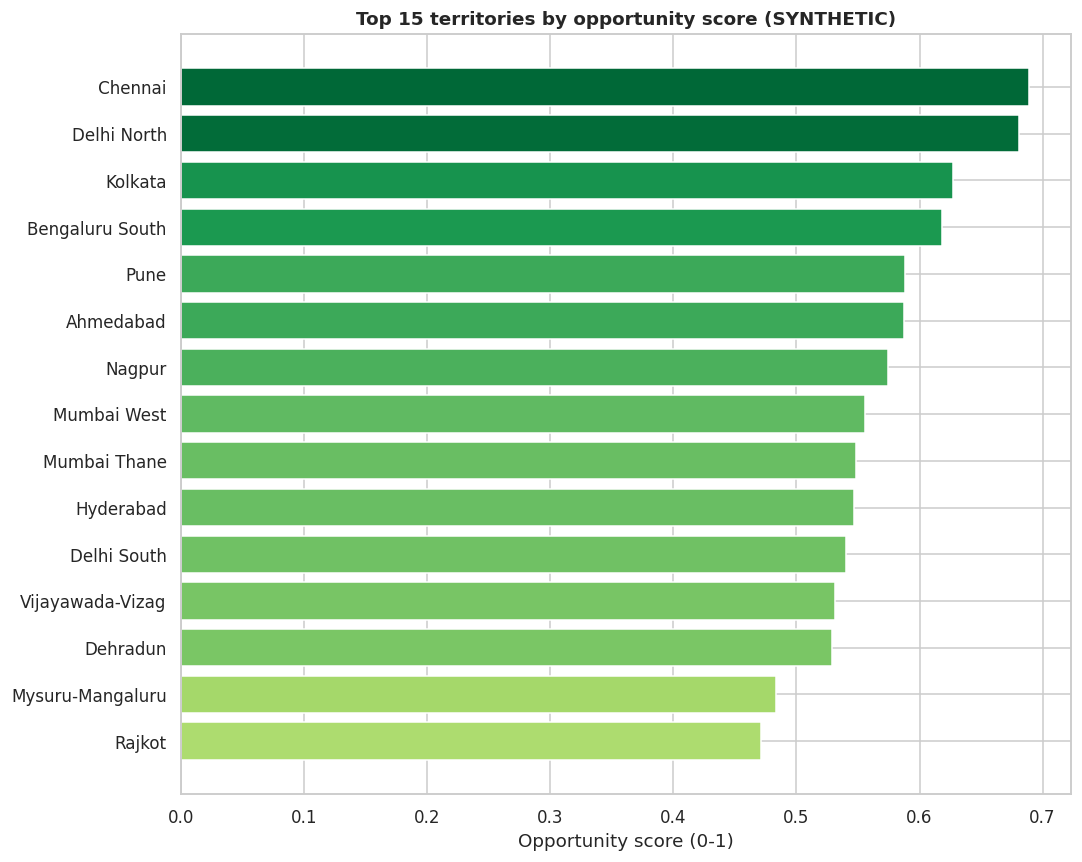

In [7]:
fig, ax = plt.subplots(figsize=(10,8))
top15 = final.head(15).sort_values('opportunity_score')
colors = plt.cm.RdYlGn(top15.opportunity_score / top15.opportunity_score.max())
ax.barh(top15.territory, top15.opportunity_score, color=colors)
ax.set_xlabel('Opportunity score (0-1)')
ax.set_title('Top 15 territories by opportunity score (SYNTHETIC)', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(OUT + '13_top_territories.png', dpi=150)
plt.show()


## Summary

- Built a 6-factor weighted opportunity score, differentiating HCP behavioural opportunity from brand awareness gap (an improvement on the SQL preview's coarser proxy).
- Tested the model's sensitivity to its own weights across 12 perturbations (±10 points on each of the 6 weights) — the minimum Spearman rank correlation vs the base ranking is printed in Section 4 above, and stayed comfortably above the 0.90 threshold used as the bar for "robust."
- Saved `territory_opportunity_ranked.csv` for use in the dashboard's Territory Prioritization page.

**Caveat, stated plainly**: this ranks *synthetic* territories built from *assumed* market potential and *simulated* HCP behaviour. The method — normalise, weight, rank, then test sensitivity — is the reusable and defensible part. The specific ranking would need to be rebuilt on real distribution and HCP data before it drove an actual resourcing decision.

**Next:** `05_scenario_model.ipynb` builds Base/Upside/Conservative scenarios for what winning back these territories could be worth.
